
Comparison of runs
-----------------------------------------------------------------------------------------------
     h         avg(y)      avg error    x near 15        Euler y        Exact y    local error
-----------------------------------------------------------------------------------------------
  0.01       1.910827       0.368593    15.000000       0.231440       0.272375       0.040935
  0.05       1.018602       1.259614    15.000000       0.119869       0.272375       0.152506
  0.15       0.320505       1.955839    15.000000       0.020921       0.272375       0.251454
  0.20       0.204568       2.067651    15.000000       0.007903       0.272375       0.264472
  0.25       0.136335       2.140288    15.000000       0.002662       0.272375       0.269713
  0.30       0.091602       2.185167    15.000000       0.000753       0.272375       0.271622
  0.35       0.061013       2.215906    15.050000       0.000170       0.294342       0.294172
  0.40       0.039514       

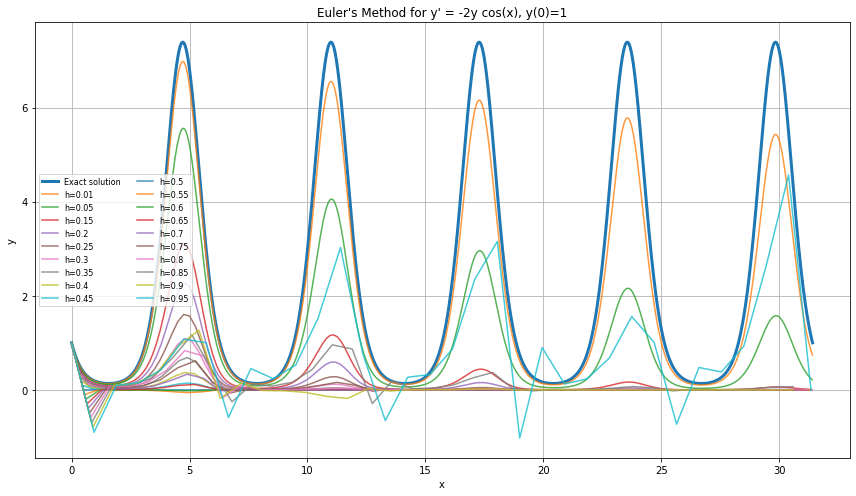

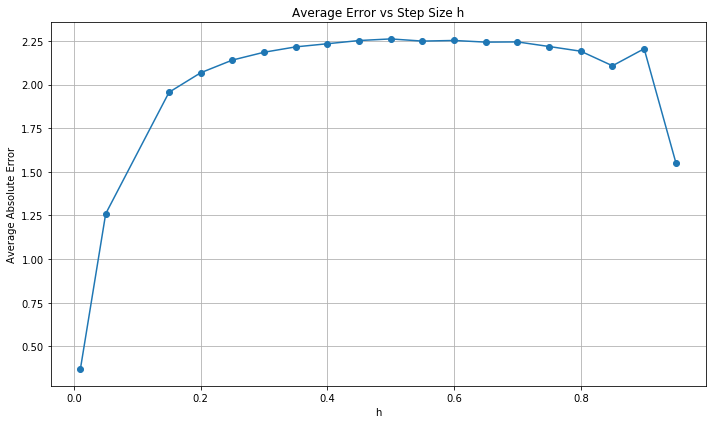

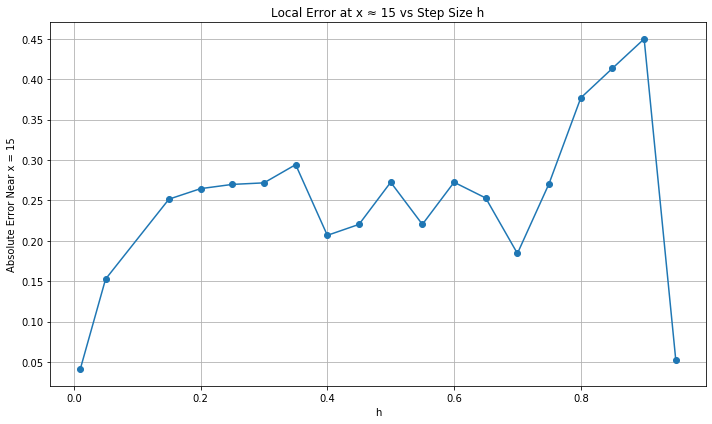

In [3]:
# Mrinal Pradhan
# Homework 7
# Euler's Method

import numpy as np
import matplotlib.pyplot as plt

# Euler's Method for y' = -2y cos(x), y(0) = 1 on [0, 10pi]

# Differential equation
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution
def exact(x):
    return np.exp(-2 * np.sin(x))

# Euler solver
def euler_method(f, x0, y0, x_end, h):
    n_steps = int(np.floor((x_end - x0) / h))
    x = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)

    x[0] = x0
    y[0] = y0

    for i in range(n_steps):
        x[i + 1] = x[i] + h
        y[i + 1] = y[i] + h * f(x[i], y[i])

    return x, y

# Problem setup
x0 = 0
y0 = 1
x_end = 10 * np.pi

# Step sizes
h_values = [
    0.01, 0.05, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80,
    0.85, 0.90, 0.95]

# Store results
results = []

# Run Euler's method for each h
for h in h_values:
    x, y = euler_method(f, x0, y0, x_end, h)
    y_true = exact(x)

    # Average y-value for this run
    avg_y = np.mean(y)

    # Pointwise absolute error against exact solution
    pointwise_error = np.abs(y - y_true)

    # Average error for this run
    avg_error = np.mean(pointwise_error)

    # Find point closest to x = 15
    idx_15 = np.argmin(np.abs(x - 15))
    x_close_15 = x[idx_15]
    y_close_15 = y[idx_15]
    y_true_15 = exact(x_close_15)

    # "Local error at x ≈ 15"
    # For this assignment, we use the actual absolute error at the point near x=15
    local_error_15 = abs(y_close_15 - y_true_15)

    results.append({
        "h": h,
        "x": x,
        "y": y,
        "y_true": y_true,
        "avg_y": avg_y,
        "avg_error": avg_error,
        "x_close_15": x_close_15,
        "y_close_15": y_close_15,
        "y_true_15": y_true_15,
        "local_error_15": local_error_15})

# Print comparison table
print("\nComparison of runs")
print("-" * 95)
print(f"{'h':>6} {'avg(y)':>14} {'avg error':>14} {'x near 15':>12} {'Euler y':>14} {'Exact y':>14} {'local error':>14}")
print("-" * 95)

for r in results:
    print(f"{r['h']:>6.2f} "
          f"{r['avg_y']:>14.6f} "
          f"{r['avg_error']:>14.6f} "
          f"{r['x_close_15']:>12.6f} "
          f"{r['y_close_15']:>14.6f} "
          f"{r['y_true_15']:>14.6f} "
          f"{r['local_error_15']:>14.6f}")


# Plot 1: Euler solutions for every h, with exact solution
plt.figure(figsize=(12, 7))

# Exact solution 
x_dense = np.linspace(x0, x_end, 4000)
y_dense = exact(x_dense)
plt.plot(x_dense, y_dense, linewidth=3, label="Exact solution")

for r in results:
    plt.plot(r["x"], r["y"], alpha=0.8, label=f"h={r['h']}")

plt.title("Euler's Method for y' = -2y cos(x), y(0)=1")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Average error vs h
plt.figure(figsize=(10, 6))
plt.plot(
    [r["h"] for r in results],
    [r["avg_error"] for r in results],
    marker='o'
)
plt.title("Average Error vs Step Size h")
plt.xlabel("h")
plt.ylabel("Average Absolute Error")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Local error at x ≈ 15 vs h
plt.figure(figsize=(10, 6))
plt.plot(
    [r["h"] for r in results],
    [r["local_error_15"] for r in results],
    marker='o')
plt.title("Local Error at x ≈ 15 vs Step Size h")
plt.xlabel("h")
plt.ylabel("Absolute Error Near x = 15")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Smaller step sizes usually give Euler curves that stay closer to the exact solution.")
# As h gets larger, the approximation becomes less accurate because Euler's method uses a straight-line step each time.")
# The average error generally increases as h increases.")
# The error near x ≈ 15 also usually grows for larger h, although it may not increase perfectly smoothly.")
# This happens because the slope depends on both y and cos(x), so the direction and size of the slope keep changing as x changes.")

# Stability analysis
# The stability depends on lambda(𝑥)=−2cos(𝑥), so the method is locally stable when |1−2hcos(x)∣<1, and in the worst case this gives 0<h<1.